## <span style='text-decoration: double underline;color:rgb(10,110,217)'>**Results Model 010**</span>

**Loss function configuration:**

$\lambda_{init} = 0$  
$\lambda_{phys} = 1$  
$\lambda_{bin} = 0$

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../')

In [3]:
import utils.evaluation_tools as eval_tools

delta = 1 
shape = (25,25)
model_name = 'DiffGoLFin'
parent_folder = '../Data'
seed2plot = 221
seeds = [221, 502, 700, 1204, 3340, 4501, 6054, 6621,8421, 15678, 19302, 38475, 77293, 91827, 99100]  

threshold = 0.5
figsize = (12,9)
subplots_grid = (3,3)
suptitle = 'DiffGoLFin Model'
th_ranges = [(0.45, 0.55), (0.40, 0.60), (0.35, 0.65)]

train_history_paths = eval_tools.get_paths_results('train_history.csv', parent_folder, seeds, shape, delta, model_name)
predictions_paths = eval_tools.get_paths_results('predictions.csv', parent_folder, seeds, shape, delta, model_name)
test_results_paths = eval_tools.get_paths_results('test_results.csv', parent_folder, seeds, shape, delta, model_name)
test_data = eval_tools.get_paths_results('test.npz', parent_folder, seeds, shape, delta, model_name)

### <span style='color:rgb(10,110,217)'><u>**Train Results**</u></span>

--- Metrics computed during execution ---
loss: 0.2381 ± 0.7605
val_loss: 0.2383 ± 0.7603


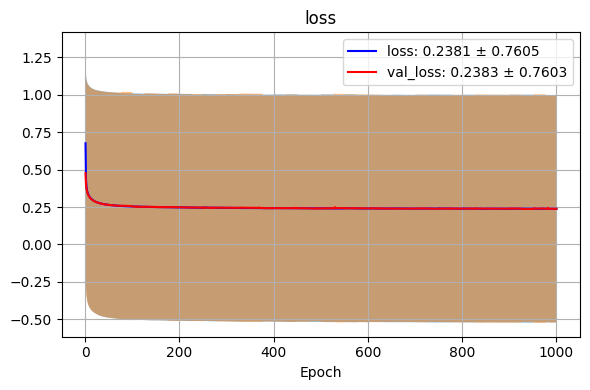

In [4]:
cols2omit = 1
num_rows = 1
eval_tools.display_results(train_history_paths, 'val_', cols2omit, num_rows, True, True)

### <span style='color:rgb(10,110,217)'><u>**Test Results**</u></span>

In [5]:
# Test:
eval_tools.display_results(test_results_paths, '_fin', display_plot=False)

--- Metrics computed during execution ---
Accuracy_init: 0.3058 ± 0.0080
Accuracy_fin: 0.9740 ± 0.0464
Recall_init: 0.2778 ± 0.1787
Recall_fin: 0.8766 ± 0.2343
Specificity_init: 0.3131 ± 0.0565
Specificity_fin: 0.9982 ± 0.0005
Precision_init: 0.0910 ± 0.0334
Precision_fin: 0.9259 ± 0.2475
F1Score_init: 0.1363 ± 0.0575
F1Score_fin: 0.9006 ± 0.2407


--- Results Initial States (15 seeds) ---
Density (true): 20.71% ± 8.76%
Density (pred): 59.02% ± 13.33%
Error/seed:     38.31% ± 0.73%
Max value predicted: 1.0000
HUC% (0.45, 0.55): 9.63% ± 4.03%
HUC% (0.4, 0.6): 18.82% ± 7.43%
HUC% (0.35, 0.65): 27.19% ± 10.70%
Fuzziness Index: 0.4341 ± 0.1700
MSE (prob):0.5673 ± 0.1461
MSE (bin):0.6942 ± 0.1052
MSE (all-zero): 0.2071 ± 0.0876
Wasserstein (EMD): 3.8374 ± 0.2227


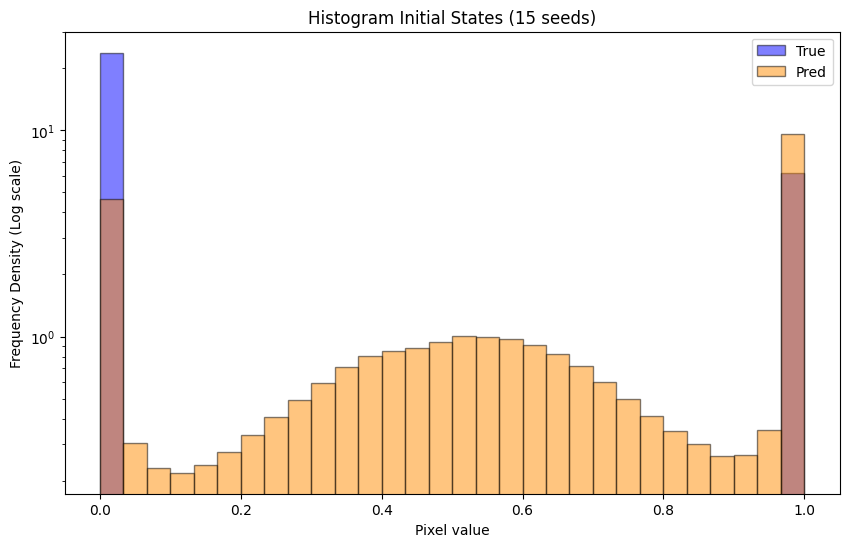

In [6]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'init', th_ranges, threshold, colors=['blue', 'darkorange'])

--- Results Final States (15 seeds) ---
Density (true): 19.93% ± 8.62%
Density (pred): 17.30% ± 6.96%
Error/seed:     2.64% ± 4.79%
Max value predicted: 1.0000
HUC% (0.45, 0.55): 0.52% ± 0.14%
HUC% (0.4, 0.6): 1.06% ± 0.29%
HUC% (0.35, 0.65): 1.64% ± 0.45%
Fuzziness Index: 0.0690 ± 0.0594
MSE (prob):0.0234 ± 0.0532
MSE (bin):0.0260 ± 0.0536
MSE (all-zero): 0.1993 ± 0.0862
Wasserstein (EMD): 1.8935 ± 3.4343


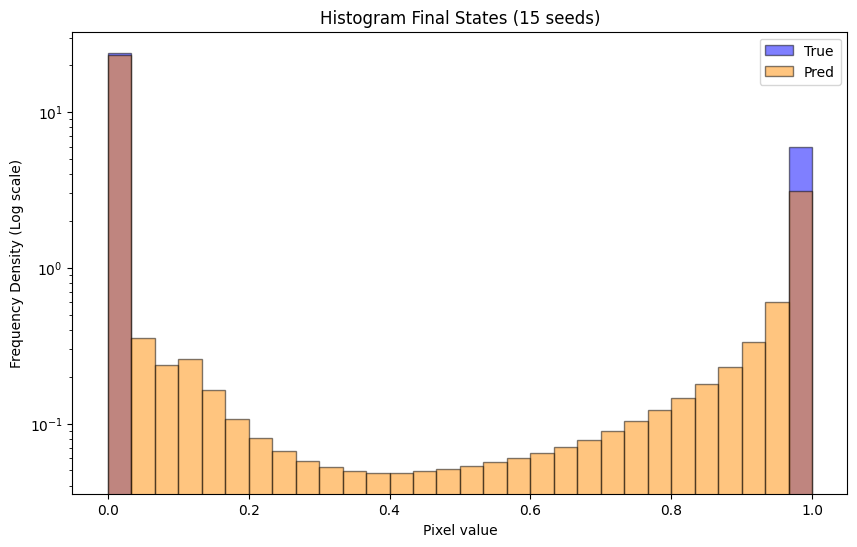

In [7]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'fin', th_ranges, threshold, colors=['blue', 'darkorange'])

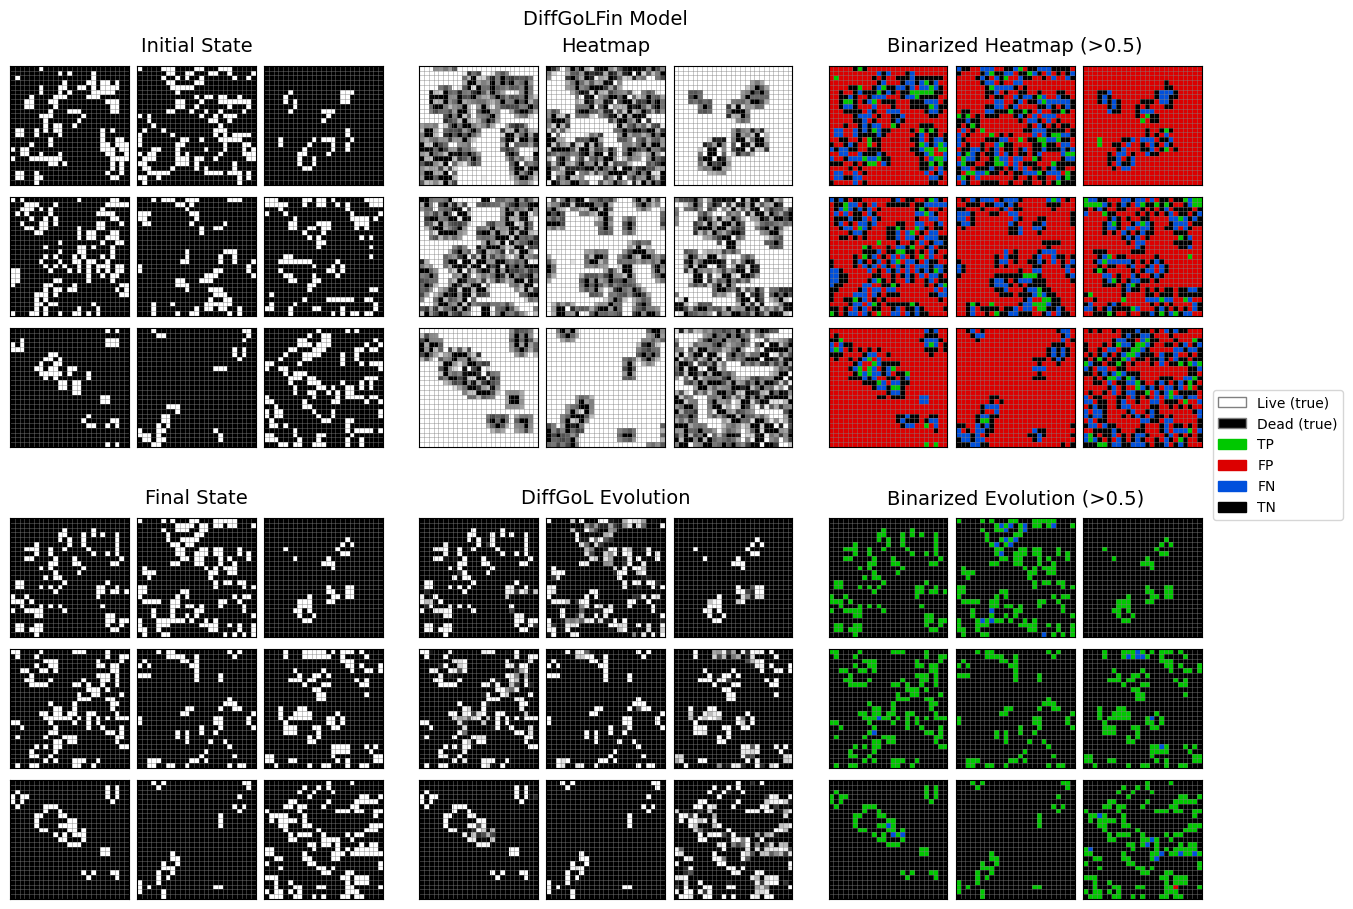

In [8]:
file_test = test_data[seed2plot]
file_pred = predictions_paths[seed2plot]
titles = ['Initial State', 'Heatmap', f'Binarized Heatmap (>{threshold})', 
          'Final State', 'DiffGoL Evolution', f'Binarized Evolution (>{threshold})']
eval_tools.display_states(file_pred, file_test, shape, threshold, titles, subplots_grid, suptitle, figsize, random=False)